## Cricket Summary

In [102]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

### Define a state

In [103]:
class BatsmanState(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int

    sr : float
    bpb : float
    boundry_percent : float
    summary : str

### Define a graph

In [104]:
graph = StateGraph(BatsmanState)

### Define Nodes

In [105]:
def strike_rate(state: BatsmanState):
    sr = (state['runs']/state['balls'])*100
    return {'sr' : sr}


def ball_per_boundry(state:BatsmanState):
    bpb = state['balls']/state['fours']+state['sixes']
    return {'bpb' : bpb}
    
def boundry_percent(state:BatsmanState):
    boundry_percentage = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100
    return {'boundry_percent' : boundry_percentage}
    
def summary(state:BatsmanState):
    summary = f"""
    Strike Rate : {state['sr']}
    Balls / Boundry : {state['bpb']}
    Boundry % age : {state['boundry_percent']}
    """
    return {'summary': summary}
    

graph.add_node('strike_rate', strike_rate)
graph.add_node('ball_per_boundry', ball_per_boundry)
graph.add_node('boundry_percent', boundry_percent)
graph.add_node('summary', summary)

### Define Edges

In [106]:
graph.add_edge(START, 'strike_rate')
graph.add_edge(START, 'ball_per_boundry')
graph.add_edge(START, 'boundry_percent')
graph.add_edge('strike_rate', 'summary')
graph.add_edge('ball_per_boundry', 'summary')
graph.add_edge('boundry_percent', 'summary')
graph.add_edge('summary',END)

### Compile Graph

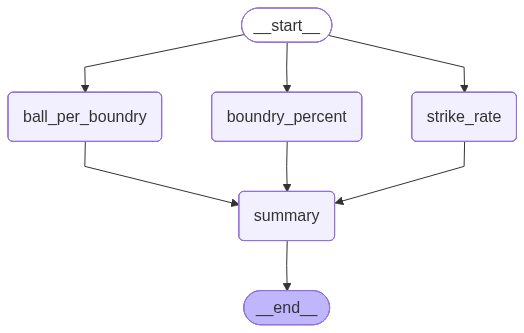

In [107]:
workflow = graph.compile()
graph.compile()

### Execute Graph

In [108]:
initial_state = {
    'runs' : 100,
    'balls' : 50,
    'fours' : 6,
    'sixes' : 4
}

final_state = workflow.invoke(initial_state)
print(final_state['summary'])


    Strike Rate : 200.0
    Balls / Boundry : 12.333333333333334
    Boundry % age : 48.0
    
